# Première lecture des documents FOMC

Point de départ : `data/raw/fomc_documents_raw.csv`.

In [1]:
import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomc_nlp_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)

In [2]:
ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "fomc_documents_raw.csv").exists():
    ROOT = ROOT.parent

raw_path = ROOT / "data" / "raw" / "fomc_documents_raw.csv"
raw = pd.read_csv(raw_path, parse_dates=["date"])
raw.head(1)

,date,year,meeting_id,statement_url,minutes_url,statement_text,minutes_text,statement_download_error,minutes_download_error
0,2000-02-02,2000,2000-02-02,https://www.federalreserve.gov/boarddocs/press/general/2000/20000202/,https://www.federalreserve.gov/fomc/minutes/20000202.htm,"Release Date: February 2, 2000 For immediate release The Federal Open Market Committee voted today to raise its target for the federal funds rate by 25 basis points to 5-3/4 pe...","Minutes of the Federal Open Market Committee February 1-2, 2000 A meeting of the Federal Open Market Committee was held in the offices of the Board of Governors of the Federal ...",NaN,NaN


Premier aperçu du fichier chargé.

In [3]:
pd.Series({
    "rows": len(raw),
    "first_date": raw["date"].min().date(),
    "last_date": raw["date"].max().date(),
    "duplicated_dates": raw["date"].duplicated().sum(),
    "empty_statements": raw["statement_text"].fillna("").str.len().eq(0).sum(),
    "empty_minutes": raw["minutes_text"].fillna("").str.len().eq(0).sum(),
})

rows                       199
first_date          2000-02-02
last_date           2024-12-18
duplicated_dates             0
empty_statements             0
empty_minutes                0
dtype: object

199 réunions entre 2000 et 2024. Les deux textes sont présents à chaque fois.

Nettoyage : minuscules, espaces propres, comptage de mots par regex.

In [4]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)

def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace(" ", " ")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def count_words(text):
    return len(TOKEN_RE.findall(clean_text(text)))

df = raw.assign(**{
    "statement_clean_text": raw["statement_text"].map(clean_text),
    "minutes_clean_text": raw["minutes_text"].map(clean_text),
    "statement_n_words": raw["statement_text"].map(count_words),
    "minutes_n_words": raw["minutes_text"].map(count_words),
})

df[["date", "statement_n_words", "minutes_n_words"]].head()

,date,statement_n_words,minutes_n_words
0,2000-02-02,202,8319
1,2000-03-21,208,4434
2,2000-05-16,202,4072
3,2000-06-28,178,4345
4,2000-08-22,181,4208


In [5]:
lengths = pd.concat([
    df[["date", "year", "statement_n_words"]].rename(columns={"statement_n_words": "n_words"}).assign(document_type="statement"),
    df[["date", "year", "minutes_n_words"]].rename(columns={"minutes_n_words": "n_words"}).assign(document_type="minutes"),
], ignore_index=True)

lengths.groupby("document_type")["n_words"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
document_type,,,,,,,,
minutes,199.0,7283.2,2441.3,3262.0,4870.0,7536.0,8552.5,14505.0
statement,199.0,526.1,217.4,145.0,337.0,536.0,672.0,1078.0


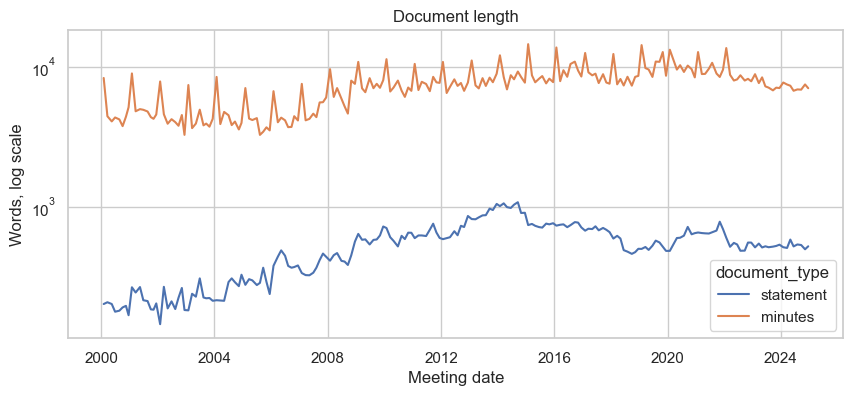

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=lengths, x="date", y="n_words", hue="document_type", ax=ax)
ax.set_yscale("log")
ax.set_title("Document length")
ax.set_xlabel("Meeting date")
ax.set_ylabel("Words, log scale");

La taille des documents tend à augmenter légèrement dans le temps. Les Minutes sont surtout beaucoup plus longues que les Statements.

Les pics réguliers dans les Minutes viennent en partie des réunions avec projections économiques, qui ajoutent plus de contenu à la publication.


#### Décision de taux

On l'extrait du Statement avec un regex.

rate_decision
hold    110
hike     59
cut      30
Name: count, dtype: int64

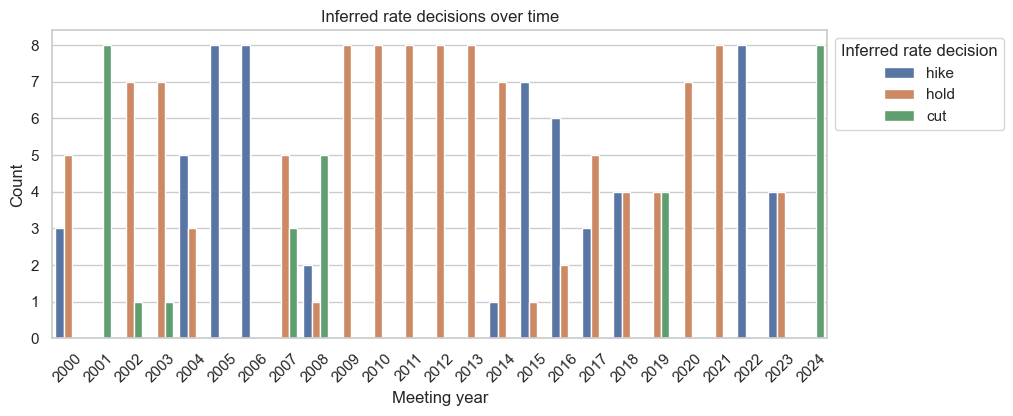

In [7]:
RATE_PATTERNS = {
    "hike": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(raise|raising|increase|increasing)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(raise|raising|increase|increasing|increased)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "cut": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "hold": [
        r"\b(decided|voted|agreed)\b.{0,80}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(will|would|shall|to)\b.{0,20}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(maintain|maintaining|keep|keeping|kept|leave|leaving)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(target range|target for the federal funds rate|federal funds rate)\b.{0,80}\b(unchanged|maintained)\b",
    ],
}

def infer_rate_decision(text):
    text = clean_text(text)
    for label in ["hike", "cut", "hold"]:
        if any(re.search(pattern, text, flags=re.DOTALL) for pattern in RATE_PATTERNS[label]):
            return label
    return "unknown"

df = df.assign(rate_decision=df["statement_text"].map(infer_rate_decision))
display(df["rate_decision"].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=df, x="year", hue="rate_decision", ax=ax)
ax.set_title("Inferred rate decisions over time")
ax.set_xlabel("Meeting year")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Inferred rate decision", loc="upper left", bbox_to_anchor=(1, 1))

In [8]:
INFLATION_TERMS = [
    "inflation", "inflationary", "price stability", "price pressures",
    "inflation expectations", "core inflation", "pce inflation", "consumer prices",
    "energy prices", "food prices", "cost pressures", "supply constraints", "disinflation",
]

LABOR_TERMS = [
    "employment", "unemployment", "labor market", "job gains", "payrolls",
    "hiring", "layoffs", "wages", "labor demand", "labor supply",
    "labor force", "slack", "participation", "vacancies", "job openings",
]

pd.DataFrame({
    "inflation": pd.Series(INFLATION_TERMS),
    "labor": pd.Series(LABOR_TERMS),
})

,inflation,labor
0,inflation,employment
1,inflationary,unemployment
2,price stability,labor market
3,price pressures,job gains
4,inflation expectations,payrolls
5,core inflation,hiring
6,pce inflation,layoffs
7,consumer prices,wages
8,energy prices,labor demand
9,food prices,labor supply


In [9]:
def count_term_occurrences(text, term):
    text = clean_text(text)
    pattern = re.escape(term.lower()).replace(r"\ ", r"\s+")
    return len(re.findall(rf"\b{pattern}\b", text))


def count_terms(text, terms):
    return sum(count_term_occurrences(text, term) for term in terms)


def add_topic_score(data, corpus, topic, terms):
    text_col = f"{corpus}_clean_text"
    n_col = f"{corpus}_n_words"
    count_col = f"{corpus}_{topic}_count"
    freq_col = f"{corpus}_{topic}_per_1000"

    counts = data[text_col].map(lambda text: count_terms(text, terms))

    return data.assign(**{
        count_col: counts,
        freq_col: lambda x: 1_000 * x[count_col] / x[n_col].replace(0, np.nan),
    })


def period_label(date):
    date = pd.Timestamp(date)
    if pd.Timestamp("2001-03-01") <= date <= pd.Timestamp("2001-11-30"):
        return "2001 recession"
    if pd.Timestamp("2007-12-01") <= date <= pd.Timestamp("2009-06-30"):
        return "GFC"
    if pd.Timestamp("2020-02-01") <= date <= pd.Timestamp("2020-06-30"):
        return "Covid shock"
    if pd.Timestamp("2021-01-01") <= date <= pd.Timestamp("2024-12-31"):
        return "post-Covid inflation"
    return "other"


PERIOD_ORDER = ["2001 recession", "GFC", "Covid shock", "post-Covid inflation", "other"]


df = (
    df.sort_values("date")
    .reset_index(drop=True)
    .pipe(add_topic_score, "statement", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "statement", "labor", LABOR_TERMS)
    .pipe(add_topic_score, "minutes", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "minutes", "labor", LABOR_TERMS)
    .assign(
        statement_balance=lambda x: x["statement_inflation_per_1000"] - x["statement_labor_per_1000"],
        minutes_balance=lambda x: x["minutes_inflation_per_1000"] - x["minutes_labor_per_1000"],
        period=lambda x: x["date"].map(period_label),
        next_rate_decision=lambda x: x["rate_decision"].shift(-1),
    )
    .assign(
        minutes_minus_statement_balance=lambda x: x["minutes_balance"] - x["statement_balance"],
        period=lambda x: pd.Categorical(x["period"], categories=PERIOD_ORDER, ordered=True),
    )
)

topic_long = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "next_rate_decision",
        "statement_inflation_per_1000", "statement_labor_per_1000",
        "minutes_inflation_per_1000", "minutes_labor_per_1000",
    ]]
    .melt(
        id_vars=["date", "year", "period", "rate_decision", "next_rate_decision"],
        var_name="measure",
        value_name="mentions_per_1000",
    )
    .assign(
        document_type=lambda x: x["measure"].str.extract(r"^(statement|minutes)")[0],
        topic=lambda x: x["measure"].str.extract(r"_(inflation|labor)_")[0],
    )
    .drop(columns="measure")
)

topic_long.head()

,date,year,period,rate_decision,next_rate_decision,mentions_per_1000,document_type,topic
0,2000-02-02,2000,other,hike,hike,14.851485,statement,inflation
1,2000-03-21,2000,other,hike,hike,14.423077,statement,inflation
2,2000-05-16,2000,other,hike,hold,14.851485,statement,inflation
3,2000-06-28,2000,other,hold,hold,16.853933,statement,inflation
4,2000-08-22,2000,other,hold,hold,16.574586,statement,inflation


In [10]:
(
    topic_long
    .groupby(["document_type", "topic"], observed=True)["mentions_per_1000"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

count   mean  median   std
document_type topic                                
minutes       inflation    199  10.58   10.20  3.72
              labor        199   5.98    6.07  2.66
statement     inflation    199  18.37   19.27  6.35
              labor        199   7.75    8.25  5.90

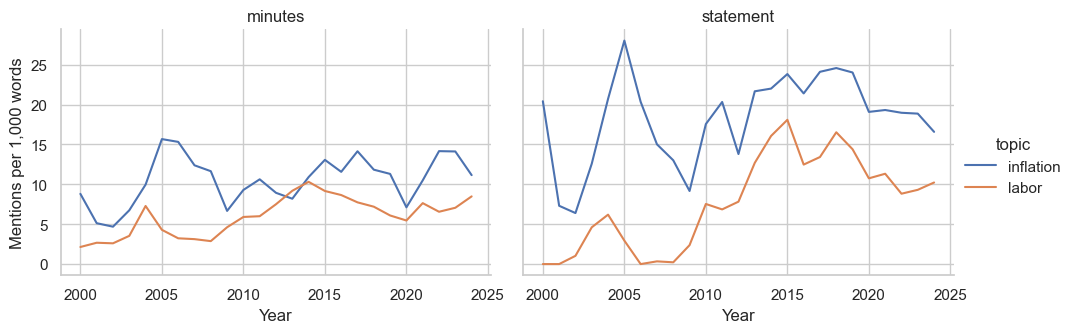

In [11]:
yearly_topics = (
    topic_long
    .groupby(["year", "document_type", "topic"], observed=True, as_index=False)["mentions_per_1000"]
    .mean()
)

g = sns.relplot(
    data=yearly_topics,
    x="year",
    y="mentions_per_1000",
    hue="topic",
    col="document_type",
    kind="line",
    height=3.5,
    aspect=1.4,
)
g.set_axis_labels("Year", "Mentions per 1,000 words")
g.set_titles("{col_name}");

In [12]:
balance_long = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "next_rate_decision",
        "statement_balance", "minutes_balance",
    ]]
    .melt(
        id_vars=["date", "year", "period", "rate_decision", "next_rate_decision"],
        value_vars=["statement_balance", "minutes_balance"],
        var_name="document_type",
        value_name="balance_per_1000",
    )
    .assign(document_type=lambda x: x["document_type"].str.replace("_balance", "", regex=False))
)

(
    balance_long
    .groupby("document_type", observed=True)["balance_per_1000"]
    .describe()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
document_type,,,,,,,,
minutes,199.0,4.60,3.98,-3.44,1.61,3.88,6.9,15.92
statement,199.0,10.62,6.09,0.00,6.60,9.49,12.6,33.61


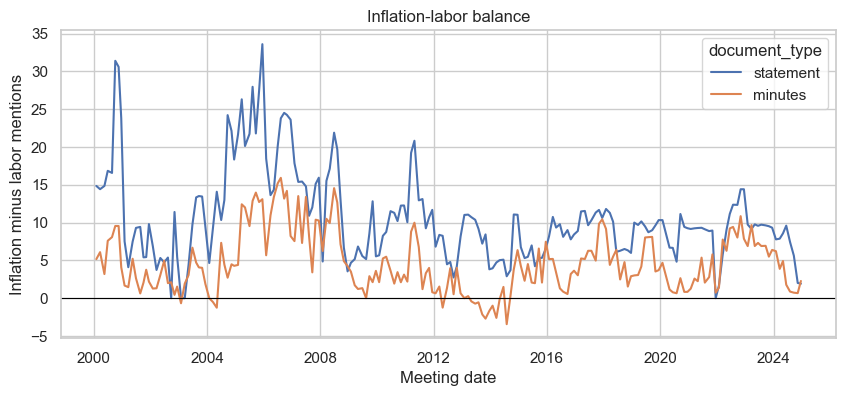

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=balance_long, x="date", y="balance_per_1000", hue="document_type", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation-labor balance")
ax.set_xlabel("Meeting date")
ax.set_ylabel("Inflation minus labor mentions");

Le score reste souvent positif : le vocabulaire d'inflation prend plus de place que celui du marché du travail.

Les dates où les deux formats divergent le plus.

In [14]:
(
    df.assign(abs_gap=lambda x: x["minutes_minus_statement_balance"].abs())
    .nlargest(12, "abs_gap")
    .loc[:, [
        "date", "period", "rate_decision", "next_rate_decision",
        "statement_balance", "minutes_balance", "minutes_minus_statement_balance",
    ]]
    .round(2)
)

/var/folders/_y/c59kgpv93ss_5wq08r4ljvrc0000gn/T/ipykernel_31297/3427125880.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,date,period,rate_decision,next_rate_decision,statement_balance,minutes_balance,minutes_minus_statement_balance
5,2000-10-03,other,hold,hold,31.41,9.55,-21.86
37,2004-09-21,other,hike,hike,24.22,2.71,-21.51
6,2000-11-15,other,hold,hold,30.61,9.55,-21.06
47,2005-12-13,other,hike,hike,33.61,13.10,-20.52
7,2000-12-19,other,hold,cut,23.81,4.09,-19.72
38,2004-11-10,other,hike,hike,22.14,4.49,-17.65
40,2005-02-02,other,hike,hike,21.66,4.40,-17.26
55,2006-12-12,other,hike,hold,23.62,8.22,-15.40
34,2004-05-04,other,hold,hike,14.08,-1.26,-15.35
44,2005-08-09,other,hike,hike,27.97,12.88,-15.10


In [15]:
term_audit_rows = []
for corpus in ["statement", "minutes"]:
    for topic, terms in {"inflation": INFLATION_TERMS, "labor": LABOR_TERMS}.items():
        text_col = f"{corpus}_clean_text"
        for term in terms:
            count = df[text_col].map(lambda text, term=term: count_term_occurrences(text, term)).sum()
            term_audit_rows.append({
                "document_type": corpus,
                "topic": topic,
                "term": term,
                "count": int(count),
            })

term_audit = pd.DataFrame(term_audit_rows)
(
    term_audit
    .sort_values(["document_type", "topic", "count"], ascending=[True, True, False])
    .groupby(["document_type", "topic"], observed=True)
    .head(5)
)

,document_type,topic,term,count
28,minutes,inflation,inflation,10387
32,minutes,inflation,inflation expectations,1587
36,minutes,inflation,energy prices,985
30,minutes,inflation,price stability,779
33,minutes,inflation,core inflation,410
41,minutes,labor,employment,2293
43,minutes,labor,labor market,2235
42,minutes,labor,unemployment,1953
53,minutes,labor,participation,444
52,minutes,labor,slack,442


In [16]:
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")
SENTENCE_ORDER = ["inflation only", "labor only", "both", "neither"]


def sentence_bucket(sentence):
    has_inflation = count_terms(sentence, INFLATION_TERMS) > 0
    has_labor = count_terms(sentence, LABOR_TERMS) > 0
    if has_inflation and has_labor:
        return "both"
    if has_inflation:
        return "inflation only"
    if has_labor:
        return "labor only"
    return "neither"


sentence_rows = []
for corpus in ["statement", "minutes"]:
    for text in df[f"{corpus}_clean_text"]:
        for sentence in SENTENCE_SPLIT_RE.split(text):
            sentence = sentence.strip()
            if sentence:
                sentence_rows.append({"document_type": corpus, "sentence_type": sentence_bucket(sentence)})

sentence_audit = pd.DataFrame(sentence_rows)
sentence_summary = (
    sentence_audit
    .value_counts(["document_type", "sentence_type"])
    .rename("sentences")
    .reset_index()
    .assign(
        sentence_type=lambda x: pd.Categorical(x["sentence_type"], categories=SENTENCE_ORDER, ordered=True),
        share=lambda x: x["sentences"] / x.groupby("document_type")["sentences"].transform("sum"),
    )
    .sort_values(["document_type", "sentence_type"])
)

sentence_summary.assign(share_pct=lambda x: 100 * x["share"]).round({"share": 3, "share_pct": 1})

,document_type,sentence_type,sentences,share,share_pct
1,minutes,inflation only,6653,0.107,10.7
2,minutes,labor only,4349,0.070,7.0
4,minutes,both,2223,0.036,3.6
0,minutes,neither,48849,0.787,78.7
5,statement,inflation only,691,0.130,13.0
7,statement,labor only,294,0.055,5.5
6,statement,both,575,0.108,10.8
3,statement,neither,3769,0.707,70.7


Lien rapide avec les décisions de taux.

Pour la corrélation, je code `cut=-1`, `hold=0`, `hike=1`.

In [17]:
DECISION_CODE = {"cut": -1, "hold": 0, "hike": 1}

df = df.assign(
    rate_decision_code=lambda x: x["rate_decision"].map(DECISION_CODE),
    next_rate_decision_code=lambda x: x["next_rate_decision"].map(DECISION_CODE),
)

(
    df.loc[:, [
        "statement_balance", "minutes_balance",
        "rate_decision_code", "next_rate_decision_code",
    ]]
    .corr()
    .loc[["statement_balance", "minutes_balance"], ["rate_decision_code", "next_rate_decision_code"]]
    .round(2)
)

,rate_decision_code,next_rate_decision_code
statement_balance,0.32,0.29
minutes_balance,0.32,0.26


La corrélation est positive avec la décision courante et avec la décision suivante. Les réunions plus orientées inflation sont plus souvent proches de hausses de taux.

In [18]:
(
    balance_long
    .groupby(["document_type", "rate_decision"], observed=True)["balance_per_1000"]
    .agg(["count", "mean", "median"])
    .round(2)
)

count   mean  median
document_type rate_decision                      
minutes       cut               30   4.52    3.82
              hike              59   7.36    6.57
              hold             110   3.14    2.62
statement     cut               30   8.60    8.65
              hike              59  13.94   11.48
              hold             110   9.38    9.27

In [19]:
(
    balance_long
    .dropna(subset=["next_rate_decision"])
    .groupby(["document_type", "next_rate_decision"], observed=True)["balance_per_1000"]
    .agg(["count", "mean", "median"])
    .round(2)
)

count   mean  median
document_type next_rate_decision                      
minutes       cut                    30   4.72    4.14
              hike                   58   6.95    6.18
              hold                  110   3.35    2.96
statement     cut                    30   8.88    8.65
              hike                   58  13.63   11.74
              hold                  110   9.58    9.33

In [20]:
(
    topic_long
    .groupby(["period", "document_type", "topic"], observed=True)["mentions_per_1000"]
    .mean()
    .unstack("topic")
    .round(2)
)

topic                               inflation  labor
period               document_type                  
2001 recession       minutes             5.50   2.87
                     statement           6.86   0.00
GFC                  minutes             9.86   3.08
                     statement          11.60   0.78
Covid shock          minutes             5.84   4.88
                     statement          15.01   8.34
post-Covid inflation minutes            12.49   7.44
                     statement          18.44   9.93
other                minutes            10.50   6.06
                     statement          19.47   8.20

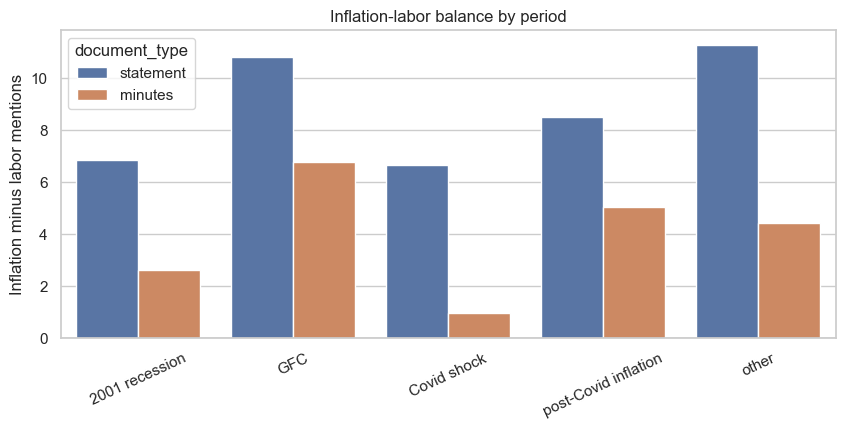

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=balance_long,
    x="period",
    y="balance_per_1000",
    hue="document_type",
    errorbar=None,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation-labor balance by period")
ax.set_xlabel("")
ax.set_ylabel("Inflation minus labor mentions")
ax.tick_params(axis="x", rotation=25);

Covid ressort différemment : le marché du travail devient beaucoup plus visible dans les Statements que dans les crises précédentes.